# Параметрическое исследование гармонического осциллятора
**Вариант №56**

## Цель исследования
Исследовать влияние параметров модели на поведение гармонического осциллятора:
* коэффициента затухания β
* частоты внешней силы ω

## Модель
Уравнение: $\ddot{x} + \beta\dot{x} + \omega_0^2 x = F_0\sin(\omega t)$
где $\omega_0^2 = 5.5$, $F_0 = 8$, начальные условия: $x_0 = -0.7$, $\dot{x}_0 = 0.8$

## Исследуемые диапазоны
* β ∈ [0.1, 5.0]
* ω ∈ [1.0, 5.0]

scripts/harmonic_parametric.jl
Параметрическое исследование гармонического осциллятора
Вариант №56

In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using Plots
using DataFrames
using LaTeXStrings
using JLD2

Создаём папки для сохранения

In [2]:
script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

println("="^60)
println("ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ГАРМОНИЧЕСКОГО ОСЦИЛЛЯТОРА")
println("Вариант №56")
println("="^60)

ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ГАРМОНИЧЕСКОГО ОСЦИЛЛЯТОРА
Вариант №56


-------------------------------------------------------------------
БАЗОВАЯ МОДЕЛЬ (случай 3 - с внешней силой)
-------------------------------------------------------------------

In [3]:
function oscillator!(du, u, p, t)
    x, y = u
    β, ω₀², F₀, ω = p  # параметры: затухание, квадрат частоты, амплитуда силы, частота силы
    du[1] = y
    du[2] = -ω₀²*x - β*y + F₀*sin(ω*t)
end

oscillator! (generic function with 1 method)

Базовые параметры (из вашего варианта)

In [4]:
base_params = [0.4, 5.5, 8.0, 3.0]  # β, ω₀², F₀, ω
u0 = [-0.7, 0.8]
tspan = (0.0, 54.0)

(0.0, 54.0)

-------------------------------------------------------------------
ИССЛЕДОВАНИЕ 1: Влияние коэффициента затухания β
-------------------------------------------------------------------

In [5]:
println("\n📊 ИССЛЕДОВАНИЕ 1: Влияние коэффициента затухания β")
println("-"^60)

β_values = [0.1, 0.4, 1.0, 2.0, 5.0]
results_β = []

p1 = plot(title="Влияние коэффициента затухания β", xlabel="Время t", ylabel="x(t)")

for β in β_values
    params = [β, base_params[2], base_params[3], base_params[4]]
    prob = ODEProblem(oscillator!, u0, tspan, params)
    sol = solve(prob, saveat=0.05)

    plot!(p1, sol.t, first.(sol.u), label="β = $β", linewidth=2)


📊 ИССЛЕДОВАНИЕ 1: Влияние коэффициента затухания β
------------------------------------------------------------


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--mathmod/labs/lab03/project/notebooks/harmonic_parametric_literate/In[5]#14:65\[90mIn[5]:14:65[0;0m]8;;\

    plot!(p1, sol.t, first.(sol.u), label="β = $β", linewidth=2)[48;2;120;70;70m[0;0m
[90m#                                                               └ ── [0;0m[91mExpected `end`[0;0m

Сохраняем результаты

In [6]:
    push!(results_β, Dict(
        :β => β,
        :max_amplitude => maximum(abs.(first.(sol.u))),
        :final_value => sol.u[end][1]
    ))
end

savefig(p1, plotsdir(script_name, "parametric_beta.png"))
println("  ✅ График сохранён: parametric_beta.png")

LoadError: UndefVarError: `β` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

-------------------------------------------------------------------
ИССЛЕДОВАНИЕ 2: Влияние частоты внешней силы ω
-------------------------------------------------------------------

In [7]:
println("\n📊 ИССЛЕДОВАНИЕ 2: Влияние частоты внешней силы ω")
println("-"^60)

ω_values = [1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
results_ω = []
resonance_curve = []

p2 = plot(title="Влияние частоты внешней силы ω", xlabel="Время t", ylabel="x(t)")

for ω in ω_values
    params = [base_params[1], base_params[2], base_params[3], ω]
    prob = ODEProblem(oscillator!, u0, tspan, params)
    sol = solve(prob, saveat=0.05)

    plot!(p2, sol.t, first.(sol.u), label="ω = $ω", linewidth=2, alpha=0.7)

    max_amp = maximum(abs.(first.(sol.u)))
    push!(results_ω, Dict(
        :ω => ω,
        :max_amplitude => max_amp
    ))
    push!(resonance_curve, (ω, max_amp))
end

savefig(p2, plotsdir(script_name, "parametric_omega.png"))
println("  ✅ График сохранён: parametric_omega.png")


📊 ИССЛЕДОВАНИЕ 2: Влияние частоты внешней силы ω
------------------------------------------------------------
  ✅ График сохранён: parametric_omega.png


-------------------------------------------------------------------
ГРАФИК РЕЗОНАНСНОЙ КРИВОЙ
-------------------------------------------------------------------

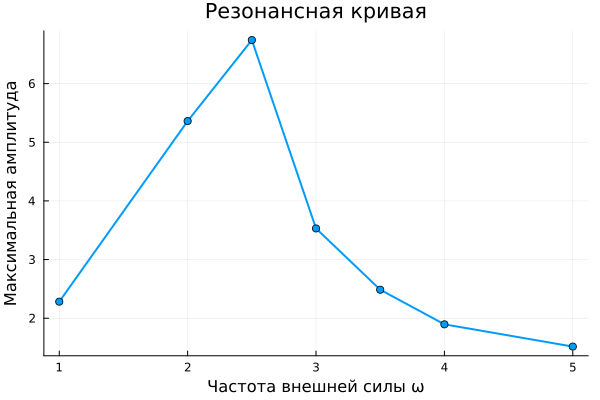

In [8]:
p3 = plot(title="Резонансная кривая",
          xlabel="Частота внешней силы ω",
          ylabel="Максимальная амплитуда")
plot!(p3, [r[1] for r in resonance_curve], [r[2] for r in resonance_curve],
      marker=:circle, linewidth=2, label="")

Отметим собственную частоту

In [9]:
ω₀ = sqrt(base_params[2])
vline!(p3, [ω₀], linestyle=:dash, linewidth=2, label="Собственная частота ω₀ = $(round(ω₀, digits=3))")

savefig(p3, plotsdir(script_name, "resonance_curve.png"))
println("  ✅ График сохранён: resonance_curve.png")

  ✅ График сохранён: resonance_curve.png


-------------------------------------------------------------------
ИССЛЕДОВАНИЕ 3: 2D-сканирование (β и ω)
-------------------------------------------------------------------

In [10]:
println("\n📊 ИССЛЕДОВАНИЕ 3: 2D-сканирование параметров")
println("-"^60)

β_range = 0.1:0.3:2.0
ω_range = 1.0:0.5:5.0

heatmap_data = zeros(length(β_range), length(ω_range))

for (i, β) in enumerate(β_range)
    for (j, ω) in enumerate(ω_range)
        params = [β, base_params[2], base_params[3], ω]
        prob = ODEProblem(oscillator!, u0, tspan, params)
        sol = solve(prob, saveat=0.05)
        heatmap_data[i, j] = maximum(abs.(first.(sol.u)))
    end
end

p4 = heatmap(ω_range, β_range, heatmap_data,
             xlabel="Частота ω", ylabel="Затухание β",
             title="2D-карта максимальной амплитуды",
             color=:viridis)

savefig(p4, plotsdir(script_name, "parametric_2d.png"))
println("  ✅ График сохранён: parametric_2d.png")


📊 ИССЛЕДОВАНИЕ 3: 2D-сканирование параметров
------------------------------------------------------------
  ✅ График сохранён: parametric_2d.png


-------------------------------------------------------------------
СВОДНЫЙ ГРАФИК
-------------------------------------------------------------------

In [11]:
p_combined = plot(p1, p2, p3, p4, layout=(2,2), size=(1200, 900))
savefig(p_combined, plotsdir(script_name, "parametric_combined.png"))

"/afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--mathmod/labs/lab03/project/plots/parametric_combined.png"

-------------------------------------------------------------------
СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
-------------------------------------------------------------------

In [12]:
println("\n📊 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
println("-"^60)


📊 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
------------------------------------------------------------


Создаём DataFrame с результатами

In [13]:
df_β = DataFrame(results_β)
df_ω = DataFrame(results_ω)

println("\nРезультаты исследования β:")
println(df_β)

println("\nРезультаты исследования ω:")
println(df_ω)


Результаты исследования β:
0×0 DataFrame

Результаты исследования ω:
7×2 DataFrame
 Row │ max_amplitude  ω       
     │ Float64        Float64 
─────┼────────────────────────
   1 │       2.28195      1.0
   2 │       5.36133      2.0
   3 │       6.74244      2.5
   4 │       3.53024      3.0
   5 │       2.4856       3.5
   6 │       1.89521      4.0
   7 │       1.51581      5.0


Сохраняем в JLD2

In [14]:
@save datadir(script_name, "parametric_results.jld2") df_β df_ω

println("\n✅ Параметрическое исследование завершено!")
println("📁 Все графики сохранены в: ", plotsdir(script_name))


✅ Параметрическое исследование завершено!
📁 Все графики сохранены в: /afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--mathmod/labs/lab03/project/plots/
